# Random Forest training and SHAP analysis

# Random Forest & SHAP Analysis for Gentrification Prediction
**Objective:** Predict the change in the "Gentrification Gap" ($\Delta G$) over a 4-year window.
**Method:** Random Forest Regressor with Leave-One-City-Out (LOCO) Cross-Validation.
**Explainability:** SHAP (SHapley Additive exPlanations) to quantify feature contribution.


In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
import shap


In [30]:

# Configuration
INPUT_PATH = "../data/processed/modeling_dataframe_universal.csv"
RANDOM_STATE = 1

# Load Data
df = pd.read_csv(INPUT_PATH)
df

,NIL,Anno,city,Gentrification_Gap,Target_Delta_Gap,Price_Z,Income_Z,Density_Z,Young_Adults_Z,Rent_Z,Estimated_Price,Median_Income_Est
0,BCN_1.0,2015.0,Barcelona,0.328767,0.232877,-0.298628,-0.867420,1.176464,2.354926,0.389996,2373.762500,26842.000000
1,BCN_1.0,2016.0,Barcelona,0.342466,0.136986,-0.042484,-0.836085,1.170323,2.281726,0.387426,2802.060000,27957.000000
2,BCN_1.0,2017.0,Barcelona,0.397260,0.027397,0.186473,-0.833881,1.189332,2.393877,0.566211,3598.077500,28431.000000
3,BCN_1.0,2018.0,Barcelona,0.698630,-0.301370,1.033328,-0.806649,1.159650,2.431218,0.711538,4887.401667,29943.000000
4,BCN_1.0,2019.0,Barcelona,0.561644,-0.356164,0.411643,-0.812456,1.166302,2.399830,0.563830,4552.625000,31472.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
865,PARCO BOSCO IN CITTA',2015.0,Milan,-0.244385,0.033289,-0.701440,-0.503290,-1.382357,0.213743,-0.691155,2204.271520,20180.730102
866,PARCO BOSCO IN CITTA',2016.0,Milan,-0.256150,0.045455,-0.743623,-0.519878,-1.385974,-0.613431,-0.731861,2115.652592,20230.074598
867,PARCO BOSCO IN CITTA',2017.0,Milan,-0.245588,0.057219,-0.786124,-0.527129,-1.390685,-0.795541,-0.777390,2064.370881,20386.889460
868,PARCO BOSCO IN CITTA',2018.0,Milan,-0.245989,0.068984,-0.779223,-0.539914,-1.391532,-0.604729,-0.768256,2104.332890,20639.737991



## 1. Data Preparation
We filter for the predictors (Z-scores) and the target ($\Delta G$).
* **Predictors:** Standardized features (`_Z`) allow the model to learn relative patterns (e.g., "High Density") rather than absolute values, which helps generalization across cities.
* **Target:** `Target_Delta_Gap`. Positive values indicate the neighborhood became *relatively more expensive* compared to local incomes (Gentrification Pressure).


In [31]:

# Define Features and Target
features = [
    'Price_Z', 
    'Income_Z', 
    'Density_Z', 
    # 'Education_Z', Milan missing education for now
    'Young_Adults_Z',
    'Rent_Z'
]
target = 'Target_Delta_Gap'
meta_cols = ['NIL', 'Anno', 'city']


df.loc[df['city'] == 'Paris', 'Rent_Z'] = 0

# Show pairs of cities and their missing features
city_feature_missing = df[meta_cols + features].isnull().groupby(df['city']).sum()
print("Missing Features by City:")
print(city_feature_missing)



# Drop rows with missing values in features or target
model_df = df.dropna(subset=features + [target]).copy()

print(f"Modeling Data Shape: {model_df.shape}")
print(f"Cities included: {model_df['city'].unique()}")


Missing Features by City:
           NIL  Anno  city  Price_Z  Income_Z  Density_Z  Young_Adults_Z  \
city                                                                       
Barcelona    0     0     0        0         0          0               0   
Milan        0     0     0        0         0          0               3   
Paris        0     0     0        0         0          0               0   

           Rent_Z  
city               
Barcelona       0  
Milan           0  
Paris           0  
Modeling Data Shape: (867, 12)
Cities included: ['Barcelona' 'Paris' 'Milan']


# Simple EDA before train

Figure saved successfully.


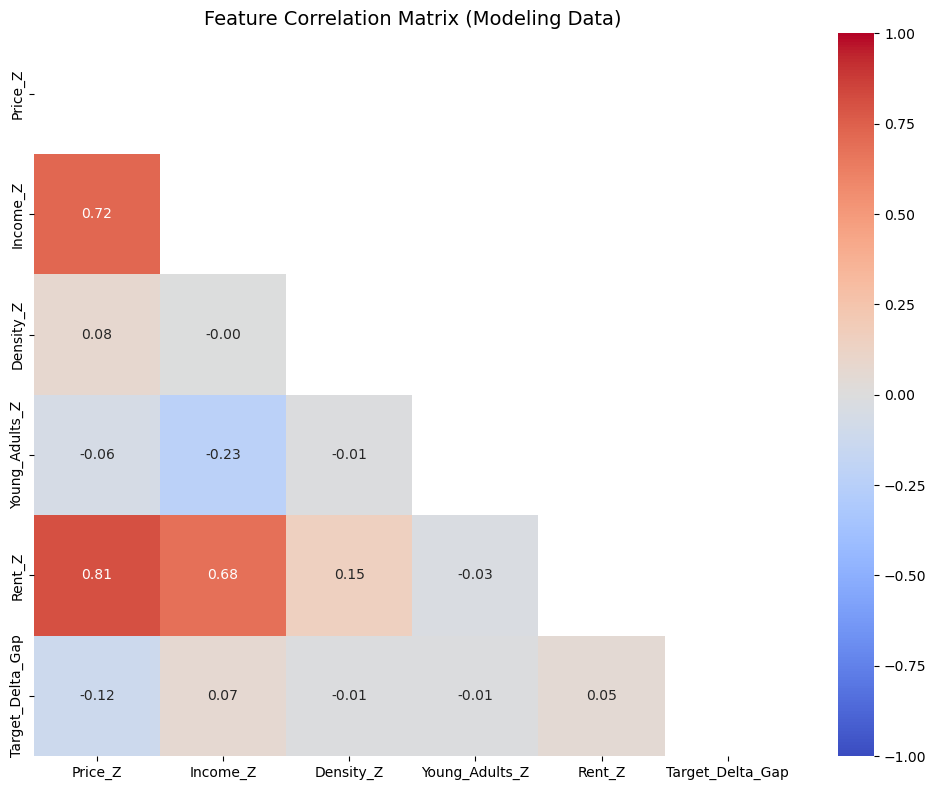

Saved: scatter_price_income.png


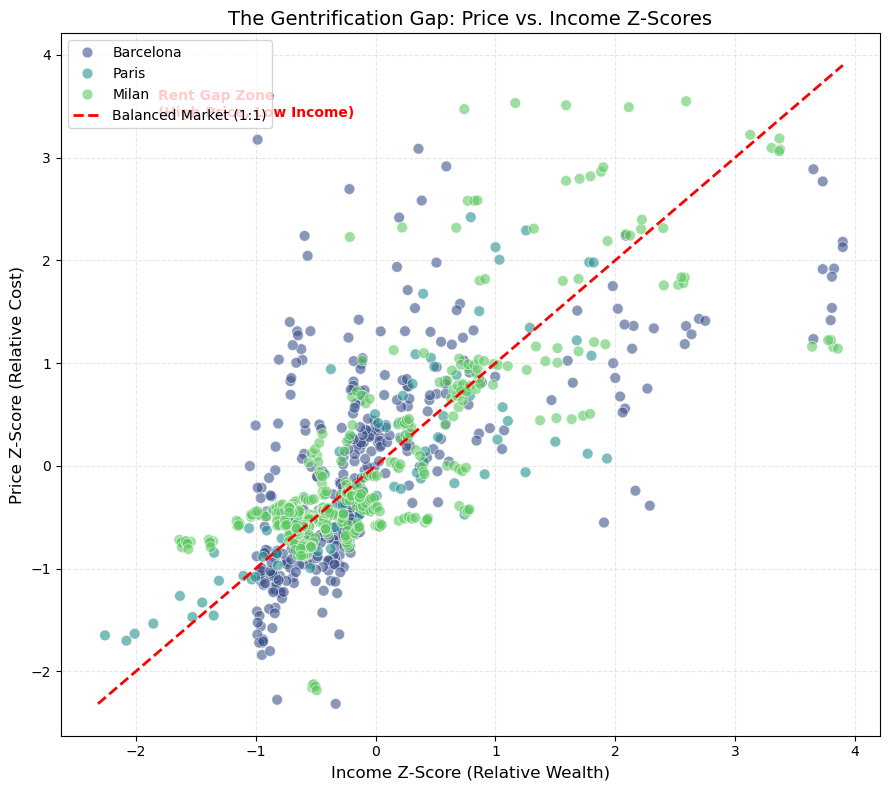

In [40]:
# Ensure libraries are imported
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- FIGURE 2: Correlation Matrix ---
def plot_correlation_matrix(data, feature_list, target_col):
    plt.figure(figsize=(10, 8))
    
    # Combine features and target for the matrix
    cols_to_plot = feature_list + [target_col]
    
    # Calculate correlation
    corr = data[cols_to_plot].corr()
    
    # Create a mask to hide the upper triangle (redundant information)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Plot heatmap
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Feature Correlation Matrix (Modeling Data)", fontsize=14)
    plt.tight_layout()
    
    # Save the figure
    plt.savefig("../data/processed/correlation_matrix.png", dpi=300) 
    print("Figure saved successfully.")
    plt.show()

# Run the function using the dataframe you prepared for modeling
# 'model_df' is likely the variable name you used in that notebook after dropping NaNs
plot_correlation_matrix(model_df, features, target)


# --- FIGURE: Price Z-Score vs Income Z-Score (The Rent Gap) ---
def plot_gentrification_gap_scatter(data):
    plt.figure(figsize=(9, 8))
    
    # Scatter plot colored by City
    sns.scatterplot(
        data=data, 
        x='Income_Z', 
        y='Price_Z', 
        hue='city', 
        alpha=0.6, 
        s=60,
        palette='viridis'
    )
    
    # Add the 1:1 Balance Line (Price = Income)
    # Get min/max to draw the line across the whole plot
    limit_min = min(data['Income_Z'].min(), data['Price_Z'].min())
    limit_max = max(data['Income_Z'].max(), data['Price_Z'].max())
    
    plt.plot([limit_min, limit_max], [limit_min, limit_max], 
             color='red', linestyle='--', linewidth=2, label='Balanced Market (1:1)')

    # Annotation for the "Gap"
    plt.text(limit_min + 0.5, limit_max - 0.5, 'Rent Gap Zone\n(High Price, Low Income)', 
             fontsize=10, color='red', weight='bold', ha='left')

    plt.title('The Gentrification Gap: Price vs. Income Z-Scores', fontsize=14)
    plt.xlabel('Income Z-Score (Relative Wealth)', fontsize=12)
    plt.ylabel('Price Z-Score (Relative Cost)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Save
    plt.tight_layout()
    plt.savefig("../data/processed/scatter_price_income.png", dpi=300)
    print("Saved: scatter_price_income.png")
    plt.show()

# Run the function
# Ensure 'model_df' is the dataframe containing your Z-scores
plot_gentrification_gap_scatter(model_df)

## 2. Leave-One-City-Out (LOCO) Validation
Because gentrification dynamics can vary by city, we test the model's ability to generalize by training on $N-1$ cities and testing on the held-out city.


In [33]:


cities = ['Paris'] # Only test with Paris for now
results = []

for holdout_city in cities:
    print(f"\n--- LOCO Fold: Holding out {holdout_city} ---")
    
    # Split Data
    train_set = model_df[model_df['city'] != holdout_city]
    test_set = model_df[model_df['city'] == holdout_city]
    
    X_train = train_set[features]
    y_train = train_set[target]
    X_test = test_set[features]
    y_test = test_set[target]
    
    # Train Model
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    
    # Predict
    y_pred = rf.predict(X_test)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    
    results.append({
        'Holdout_City': holdout_city,
        'RMSE': rmse,
        'R2': r2,
        'Train_Size': len(X_train),
        'Test_Size': len(X_test)
    })

# Summary of Results
results_df = pd.DataFrame(results)
print("\n--- LOCO Validation Summary ---")
print(results_df)


--- LOCO Fold: Holding out Paris ---
RMSE: 0.0789
R2:   -1.8275

--- LOCO Validation Summary ---
  Holdout_City      RMSE        R2  Train_Size  Test_Size
0        Paris  0.078943 -1.827462         787         80


## 3. Final Model Training & SHAP Explanation
Now we train the model on **all available data** to understand the universal drivers of gentrification across these European contexts.


Training on: ['Barcelona' 'Milan'] (787 rows)
Testing on:  ['Paris'] (80 rows)
--- Tuning Hyperparameters on Training Set ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}

🇫GENERALIZATION PERFORMANCE (PARIS):
R2 Score: -1.9512
RMSE:     0.0807


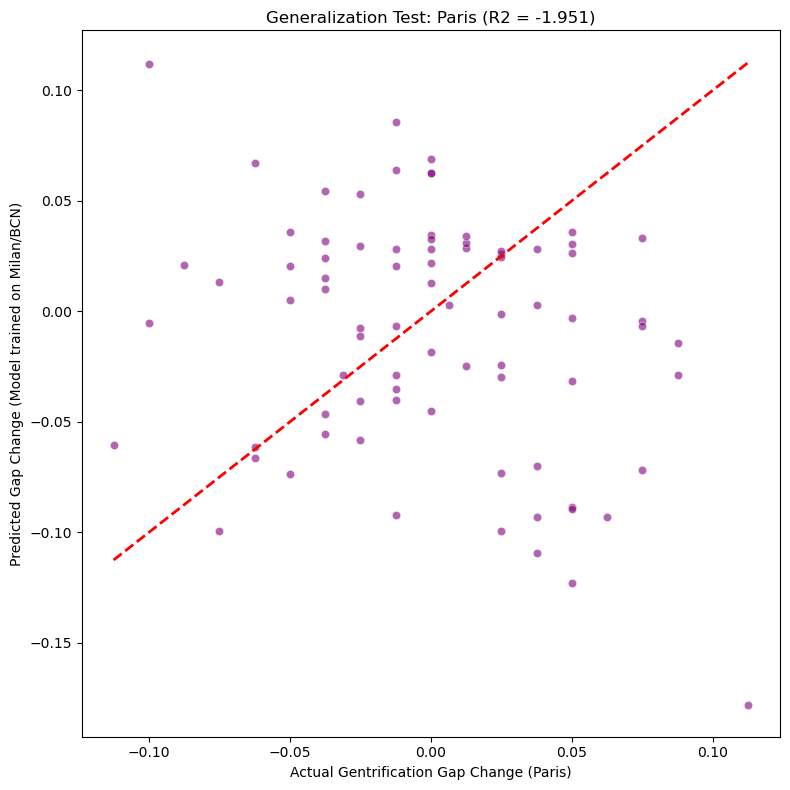

In [34]:
# --- 3. STRICT GENERALIZATION TRAINING (The "Coworker Strategy") ---

# 1. Split the world: Training (Milan + BCN) vs Generalization (Paris)
train_df = model_df[model_df['city'].isin(['Milan', 'Barcelona'])].copy()
test_df  = model_df[model_df['city'] == 'Paris'].copy()

print(f"Training on: {train_df['city'].unique()} ({len(train_df)} rows)")
print(f"Testing on:  {test_df['city'].unique()} ({len(test_df)} rows)")

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]

# 2. Hyperparameter Tuning (CV only on Milan + BCN)
# We use K-Fold here to find the best settings for Southern Europe
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [2, 4]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                 # 5-Fold Split within Milan/BCN
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("--- Tuning Hyperparameters on Training Set ---")
grid_search.fit(X_train, y_train)

# 3. Final Model Evaluation
best_rf = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")

# Predict on PARIS (The moment of truth)
y_pred_paris = best_rf.predict(X_test)
r2_paris = r2_score(y_test, y_pred_paris)
rmse_paris = np.sqrt(mean_squared_error(y_test, y_pred_paris))

print(f"\n🇫GENERALIZATION PERFORMANCE (PARIS):")
print(f"R2 Score: {r2_paris:.4f}")
print(f"RMSE:     {rmse_paris:.4f}")

# --- FIGURE 6: Paris Prediction Scatter (Save this for report!) ---
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_paris, alpha=0.6, color='purple')
# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Gentrification Gap Change (Paris)")
plt.ylabel("Predicted Gap Change (Model trained on Milan/BCN)")
plt.title(f"Generalization Test: Paris (R2 = {r2_paris:.3f})")
plt.tight_layout()
plt.savefig("../data/processed/paris_generalization_scatter.png", dpi=300)
plt.show()

### A. SHAP Summary Plot (Global Importance)
This plot shows the feature importance and the direction of the effect.
* **Red dots:** High feature value (e.g., High Income Z-score).
* **Blue dots:** Low feature value.
* **X-axis:** Impact on model output (Positive = Predicted increase in Gentrification Gap).


Calculating SHAP values for Training Set...
✅ SHAP Summary saved to ../data/processed/shap_summary.png


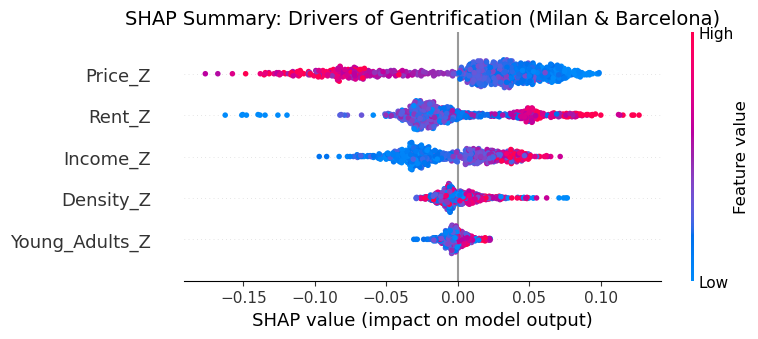

In [ ]:
# 1. Use the best model we found in the step above
final_model = grid_search.best_estimator_

# 2. Initialize Explainer
explainer = shap.TreeExplainer(final_model)

# 3. Calculate SHAP values specifically for the TRAINING set (Milan + BCN)
# We explain X_train because that is what the model "knows"
print("Calculating SHAP values for Training Set...")
shap_values = explainer.shap_values(X_train)

# 4. Generate the Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, show=False) # <--- Note: We use X_train here to match shap_values
plt.title("SHAP Summary: Drivers of Gentrification (Milan & Barcelona)", fontsize=14)
plt.tight_layout()

# Save for the report
plt.savefig("../data/processed/shap_summary.png", dpi=300)
print("SHAP Summary saved to ../data/processed/shap_summary.png")
plt.show()

### B. Feature Importance Bar Plot
A simpler view of the absolute importance of each feature.


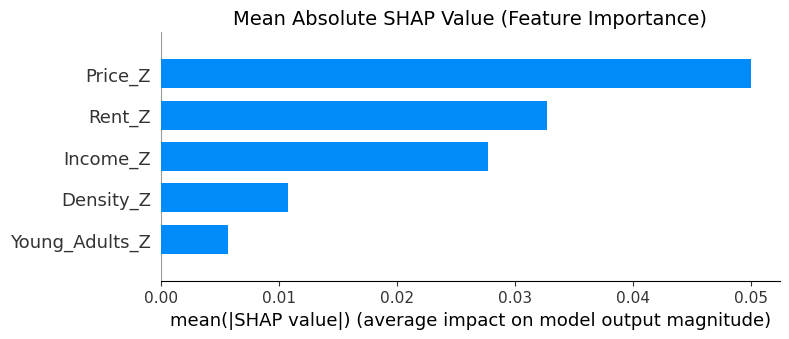

In [38]:

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Value (Feature Importance)", fontsize=14)
plt.tight_layout()
plt.show()


### C. Dependence Plots (Interaction Effects)
Let's look at the top predictor (usually Price or Income) to see if the relationship is linear or if there are thresholds (e.g., does gentrification only accelerate after a certain density?).


Generating Dependence Plot for Top Feature: Price_Z


<Figure size 800x500 with 0 Axes>

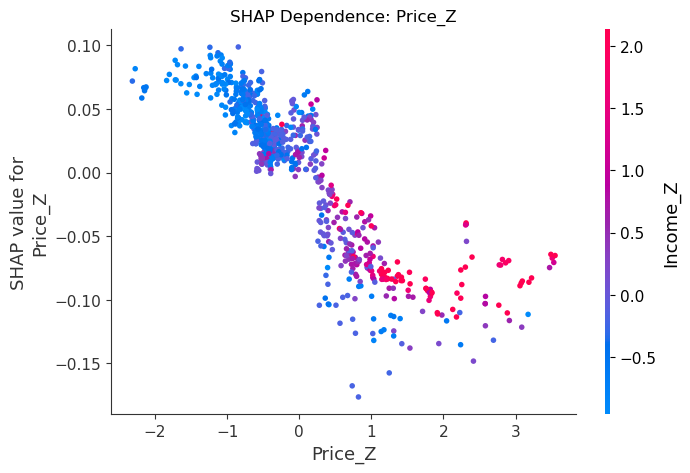

In [39]:
# Find the most important feature index
mean_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_shap)
top_feature_name = features[top_feature_idx]

print(f"Generating Dependence Plot for Top Feature: {top_feature_name}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature_name, 
    shap_values, 
    X_train, 
    interaction_index="auto", # Automatically find the feature that interacts most
    show=False
)
plt.title(f"SHAP Dependence: {top_feature_name}", fontsize=12)
plt.show()


## 4. Temporal validation


### A. All cities together

In [ ]:
# --- TEMPORAL VALIDATION (Forecasting) ---
print("\n--- TEMPORAL VALIDATION: Train on Past, Predict Future ---")

# 1. Define Cutoff
# We train on "Starts" in 2015-2017, Test on "Starts" in 2018-2019
split_year = 2018 

train_time = model_df[model_df['Anno'] < split_year]
test_time = model_df[model_df['Anno'] >= split_year]

print(f"Training on years: {train_time['Anno'].unique()}")
print(f"Testing on years:  {test_time['Anno'].unique()}")
print(f"Train Size: {len(train_time)} | Test Size: {len(test_time)}")

# 2. Train & Predict
X_train_t = train_time[features]
y_train_t = train_time[target]
X_test_t = test_time[features]
y_test_t = test_time[target]
 
rf_time = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=1)
rf_time.fit(X_train_t, y_train_t)

# 3. Evaluate
y_pred_t = rf_time.predict(X_test_t)
rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
r2_t = r2_score(y_test_t, y_pred_t)

print(f"Temporal RMSE: {rmse_t:.4f}")
print(f"Temporal R2:   {r2_t:.4f}")

# 4. Map the Temporal Error (Crucial for Analysis)
# Which neighborhoods behaved "unexpectedly" in the most recent years?
test_time = test_time.copy()
test_time['Predicted_Gap_Change'] = y_pred_t
test_time['Error'] = test_time['Predicted_Gap_Change'] - test_time['Target_Delta_Gap']

# Save for QGIS
test_time.to_csv("../data/processed/temporal_predictions_2018_2019.csv", index=False)


--- TEMPORAL VALIDATION: Train on Past, Predict Future ---
Training on years: [2015. 2016. 2017.]
Testing on years:  [2018. 2019.]
Train Size: 553 | Test Size: 314
Temporal RMSE: 0.1311
Temporal R2:   0.1531


### B. One model per city (Barcelona and Milan)


--- Analyzing Barcelona ---
Barcelona Temporal R2: 0.3177
SHAP Explanation for Barcelona:


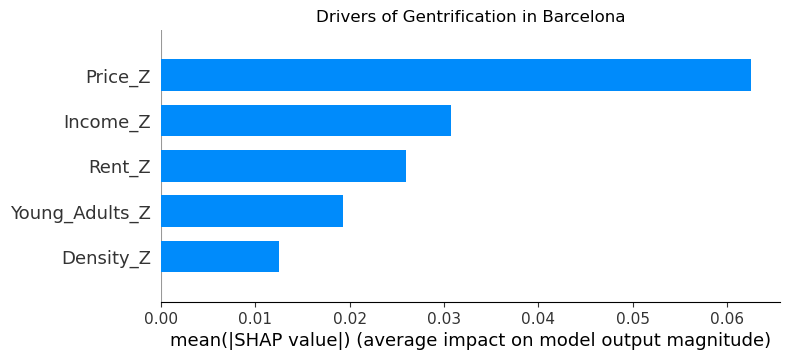

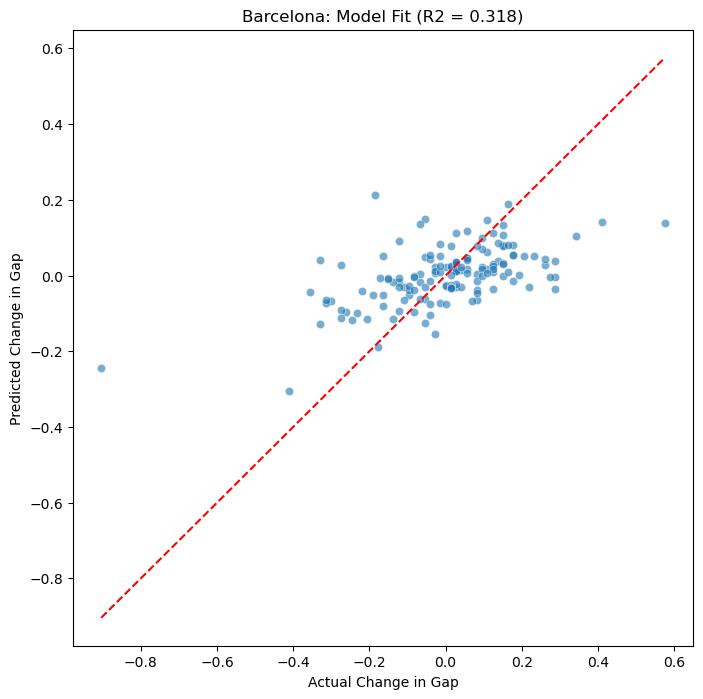


--- Analyzing Milan ---
Milan Temporal R2: 0.2856
SHAP Explanation for Milan:


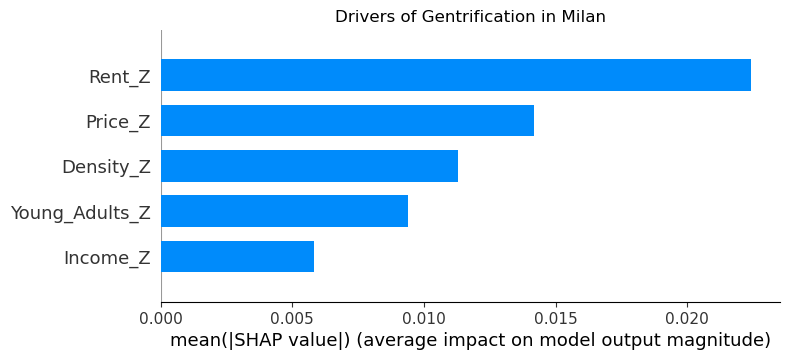

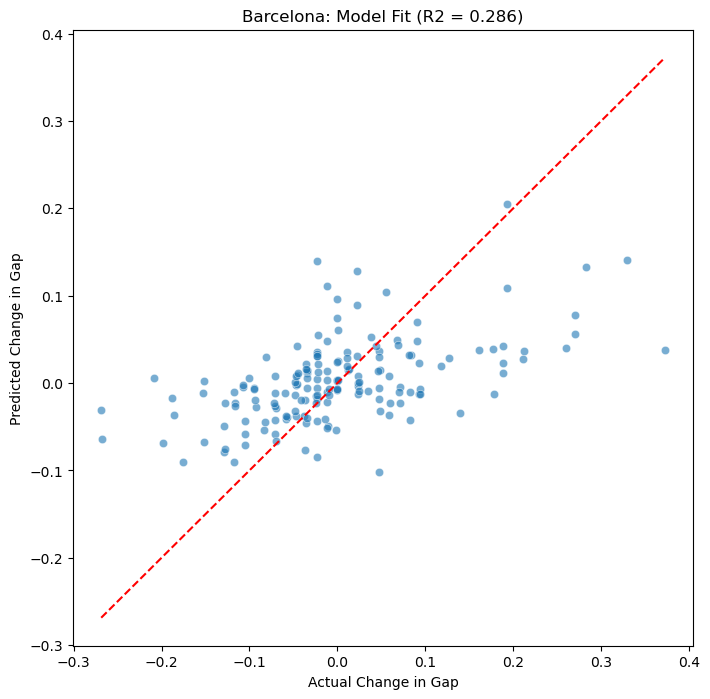

In [ ]:
# --- FINAL VALIDATION: Per-City Temporal Split ---

# List of cities that have enough history   for temporal split
# (Paris is excluded because it only has one window)
cities_with_history = ['Barcelona', 'Milan'] # Only test with Barcelona for now

for city in cities_with_history:
    print(f"\n--- Analyzing {city} ---")
    
    # 1. Isolate City Data
    city_df = model_df[model_df['city'] == city].copy()
    
    # 2. Temporal Split (Train: < 2018, Test: >= 2018)
    train = city_df[city_df['Anno'] < 2018]
    test = city_df[city_df['Anno'] >= 2018]
    
    if len(test) == 0:
        print(f"Skipping {city} (No test data in 2018+)")
        continue
        
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    # 3. Train Local Model
    rf_local = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf_local.fit(X_train, y_train)
    
    # 4. Evaluate
    y_pred = rf_local.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{city} Temporal R2: {r2:.4f}")
    
    # 5. Explain (SHAP) - What drives THIS city?
    # This is great for the report: "In BCN, Price matters most. In Milan, Density matters most?"
    explainer = shap.TreeExplainer(rf_local)
    shap_values = explainer.shap_values(X_train)
    print(f"SHAP Explanation for {city}:")
    
    plt.figure(figsize=(6, 4))
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
    plt.title(f"Drivers of Gentrification in {city}")
    plt.show()
    
        # Run this after your Barcelona validation loop
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect fit line
    plt.xlabel("Actual Change in Gap")
    plt.ylabel("Predicted Change in Gap")
    plt.title(f"Barcelona: Model Fit (R2 = {r2:.3f})")
    plt.show()

## 5. Saving Predictions for Mapping
We save the predictions back to the dataframe so you can visualize the "Predicted vs Actual" gap in QGIS or GeoPandas.


In [ ]:
model_df['Predicted_Delta_Gap'] = final_model.predict(X_full)
model_df['Prediction_Error'] = model_df['Predicted_Delta_Gap'] - model_df['Target_Delta_Gap']

output_path = "../data/processed/model_predictions_shap.csv"
model_df.to_csv(output_path, index=False)
print(f"Predictions saved to {output_path}")

Predictions saved to ../data/processed/model_predictions_shap.csv
